<h1>ENSO Index - Ensemble Means</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import xarray as xr

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.util import util, stats

import warnings
warnings.filterwarnings('ignore')

<h5>Get data readers</h5>

In [3]:
# seas5 sst data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/sst/'

In [4]:
ufs_vars_list = ['tmpsfc', 'tsfc']
era5_var = 'sea_surface_temperature'
seas5_var = 'sst'

In [5]:
ufs_experiments = ['baseline', 'beta.0.1', 'c96_beta.0.1', 'cpc_ics']

In [6]:
# Collect all sst seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [7]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [8]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                  'number': 'member'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member'})

# Wrap it up into a DataReader object.
seas5_data_reader = dr.getDataReader(datasource='SUPPLIED', dataset=seas5_ds)

In [9]:
# Get ERA5 data
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [10]:
# seas5_data_reader.describe(seas5_var)

<h5>Define time period</h5>

In [11]:
time_range = ("1994-02-01","2021-08-31T23")
initmonths = (11,)

<h5>Define nino 3.4 region</h5>

In [12]:
region = {
    'latmin': -5.0,
    'latmax': 5.0,
    'lonmin': 190.0,
    'lonmax':240.0
}

<h5>Get the monthly climatology for nino 3.4</h5>

In [15]:
%%capture captured_output
# First, collect all the ensemble means for the UFS models.
ufs_ds = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range, region=region, initmonths=initmonths)

<h5>Get the corresponding ERA5 data</h5>

In [17]:
era5_ds = era5_data_reader.retrieve(var=era5_var,
                                    lat=(region['latmin'], region['latmax']),
                                    lon=(region['lonmin'], region['lonmax']),
                                    time=time_range)

In [26]:
seas5_ds = seas5_data_reader.retrieve(var=seas5_var,
                                      lat=(region['latmin'], region['latmax']),
                                      lon=(region['lonmin'], region['lonmax']),
                                      initmonths=initmonths,
                                      time=time_range,
                                      ens_avg=True)

Taking Ensemble Average


In [20]:
ufs_ds

<xarray.Dataset> Size: 48MB
Dimensions:                (member: 4, init: 27, lead: 12, lat: 31, lon: 148)
Coordinates:
  * member                 (member) <U12 192B 'baseline' ... 'cpc_ics'
  * init                   (init) datetime64[ns] 216B 1994-11-01 ... 2020-11-01
  * lead                   (lead) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * lat                    (lat) float64 248B -5.0 -4.5 -4.208 ... 4.208 4.5 5.0
  * lon                    (lon) float64 1kB 190.0 190.3 190.5 ... 239.5 240.0
    atmosphereSingleLayer  float64 8B 0.0
    heightAboveGround      float64 8B 2.0
    meanSea                float64 8B 0.0
    nominalTop             float64 8B 0.0
    surface                float64 8B 0.0
    depthBelowLandLayer    float64 8B 0.0
Data variables:
    tmpsfc                 (member, init, lead, lat, lon) float64 48MB dask.array<chunksize=(1, 1, 1, 10, 51), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    history:                 2024-12-09T11:56 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             US National Weather Service - NCEP

In [27]:
seas5_ds

<xarray.Dataset> Size: 325kB
Dimensions:  (init: 27, lead: 6, lat: 10, lon: 50)
Coordinates:
  * init     (init) datetime64[ns] 216B 1994-11-01 1995-11-01 ... 2020-11-01
  * lead     (lead) int64 48B 1 2 3 4 5 6
  * lat      (lat) float64 80B 4.5 3.5 2.5 1.5 0.5 -0.5 -1.5 -2.5 -3.5 -4.5
  * lon      (lon) float64 400B 190.5 191.5 192.5 193.5 ... 237.5 238.5 239.5
Data variables:
    sst      (init, lead, lat, lon) float32 324kB dask.array<chunksize=(1, 3, 5, 50), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-21T20:44 GRIB to CDM+CF via cfgrib-0.9.1...

In [23]:
era5_ds

<xarray.Dataset> Size: 161MB
Dimensions:                  (time: 40296, lat: 14, lon: 71)
Coordinates:
  * time                     (time) datetime64[ns] 322kB 1994-02-01 ... 2021-...
  * lat                      (lat) float64 112B 4.57 3.867 ... -3.867 -4.57
  * lon                      (lon) float64 568B 190.5 191.2 ... 239.1 239.8
Data variables:
    sea_surface_temperature  (time, lat, lon) float32 160MB dask.array<chunksize=(112, 14, 71), meta=np.ndarray>

In [28]:
# Because both the seas5 and ufs models have init+lead structure,
# combine seas5 into the ufs dataset as a standalone "member"

# Rename to match ufs
seas5_ds = seas5_ds.rename({'sst': 'tmpsfc'})
# consider ecmwf a 'member'
seas5_ds = seas5_ds.assign_coords(member=('member', ['seas5']))
# Concatenate with ufs
ufs_ds = xr.concat([ufs_ds, seas5_ds], dim='member', coords='minimal', compat='equals')

<h5>Calculate climatology (this may take a couple minutes)</h5>

In [29]:
ufs_stats = stats.calc_climatology_anomaly(ufs_ds, area_mean=True, use_member_climatology=True)

In [30]:
era5_stats = stats.calc_climatology_anomaly(era5_ds, area_mean=True, use_member_climatology=True)

Generating 4 panel(s).
Processing years 1994 to 1999
Processing years 2000 to 2009
Processing years 2010 to 2019
Processing years 2020 to 2020


<module 'matplotlib.pyplot' from '/home/thamzey/miniforge2/envs/copernicus/lib/python3.11/site-packages/matplotlib/pyplot.py'>

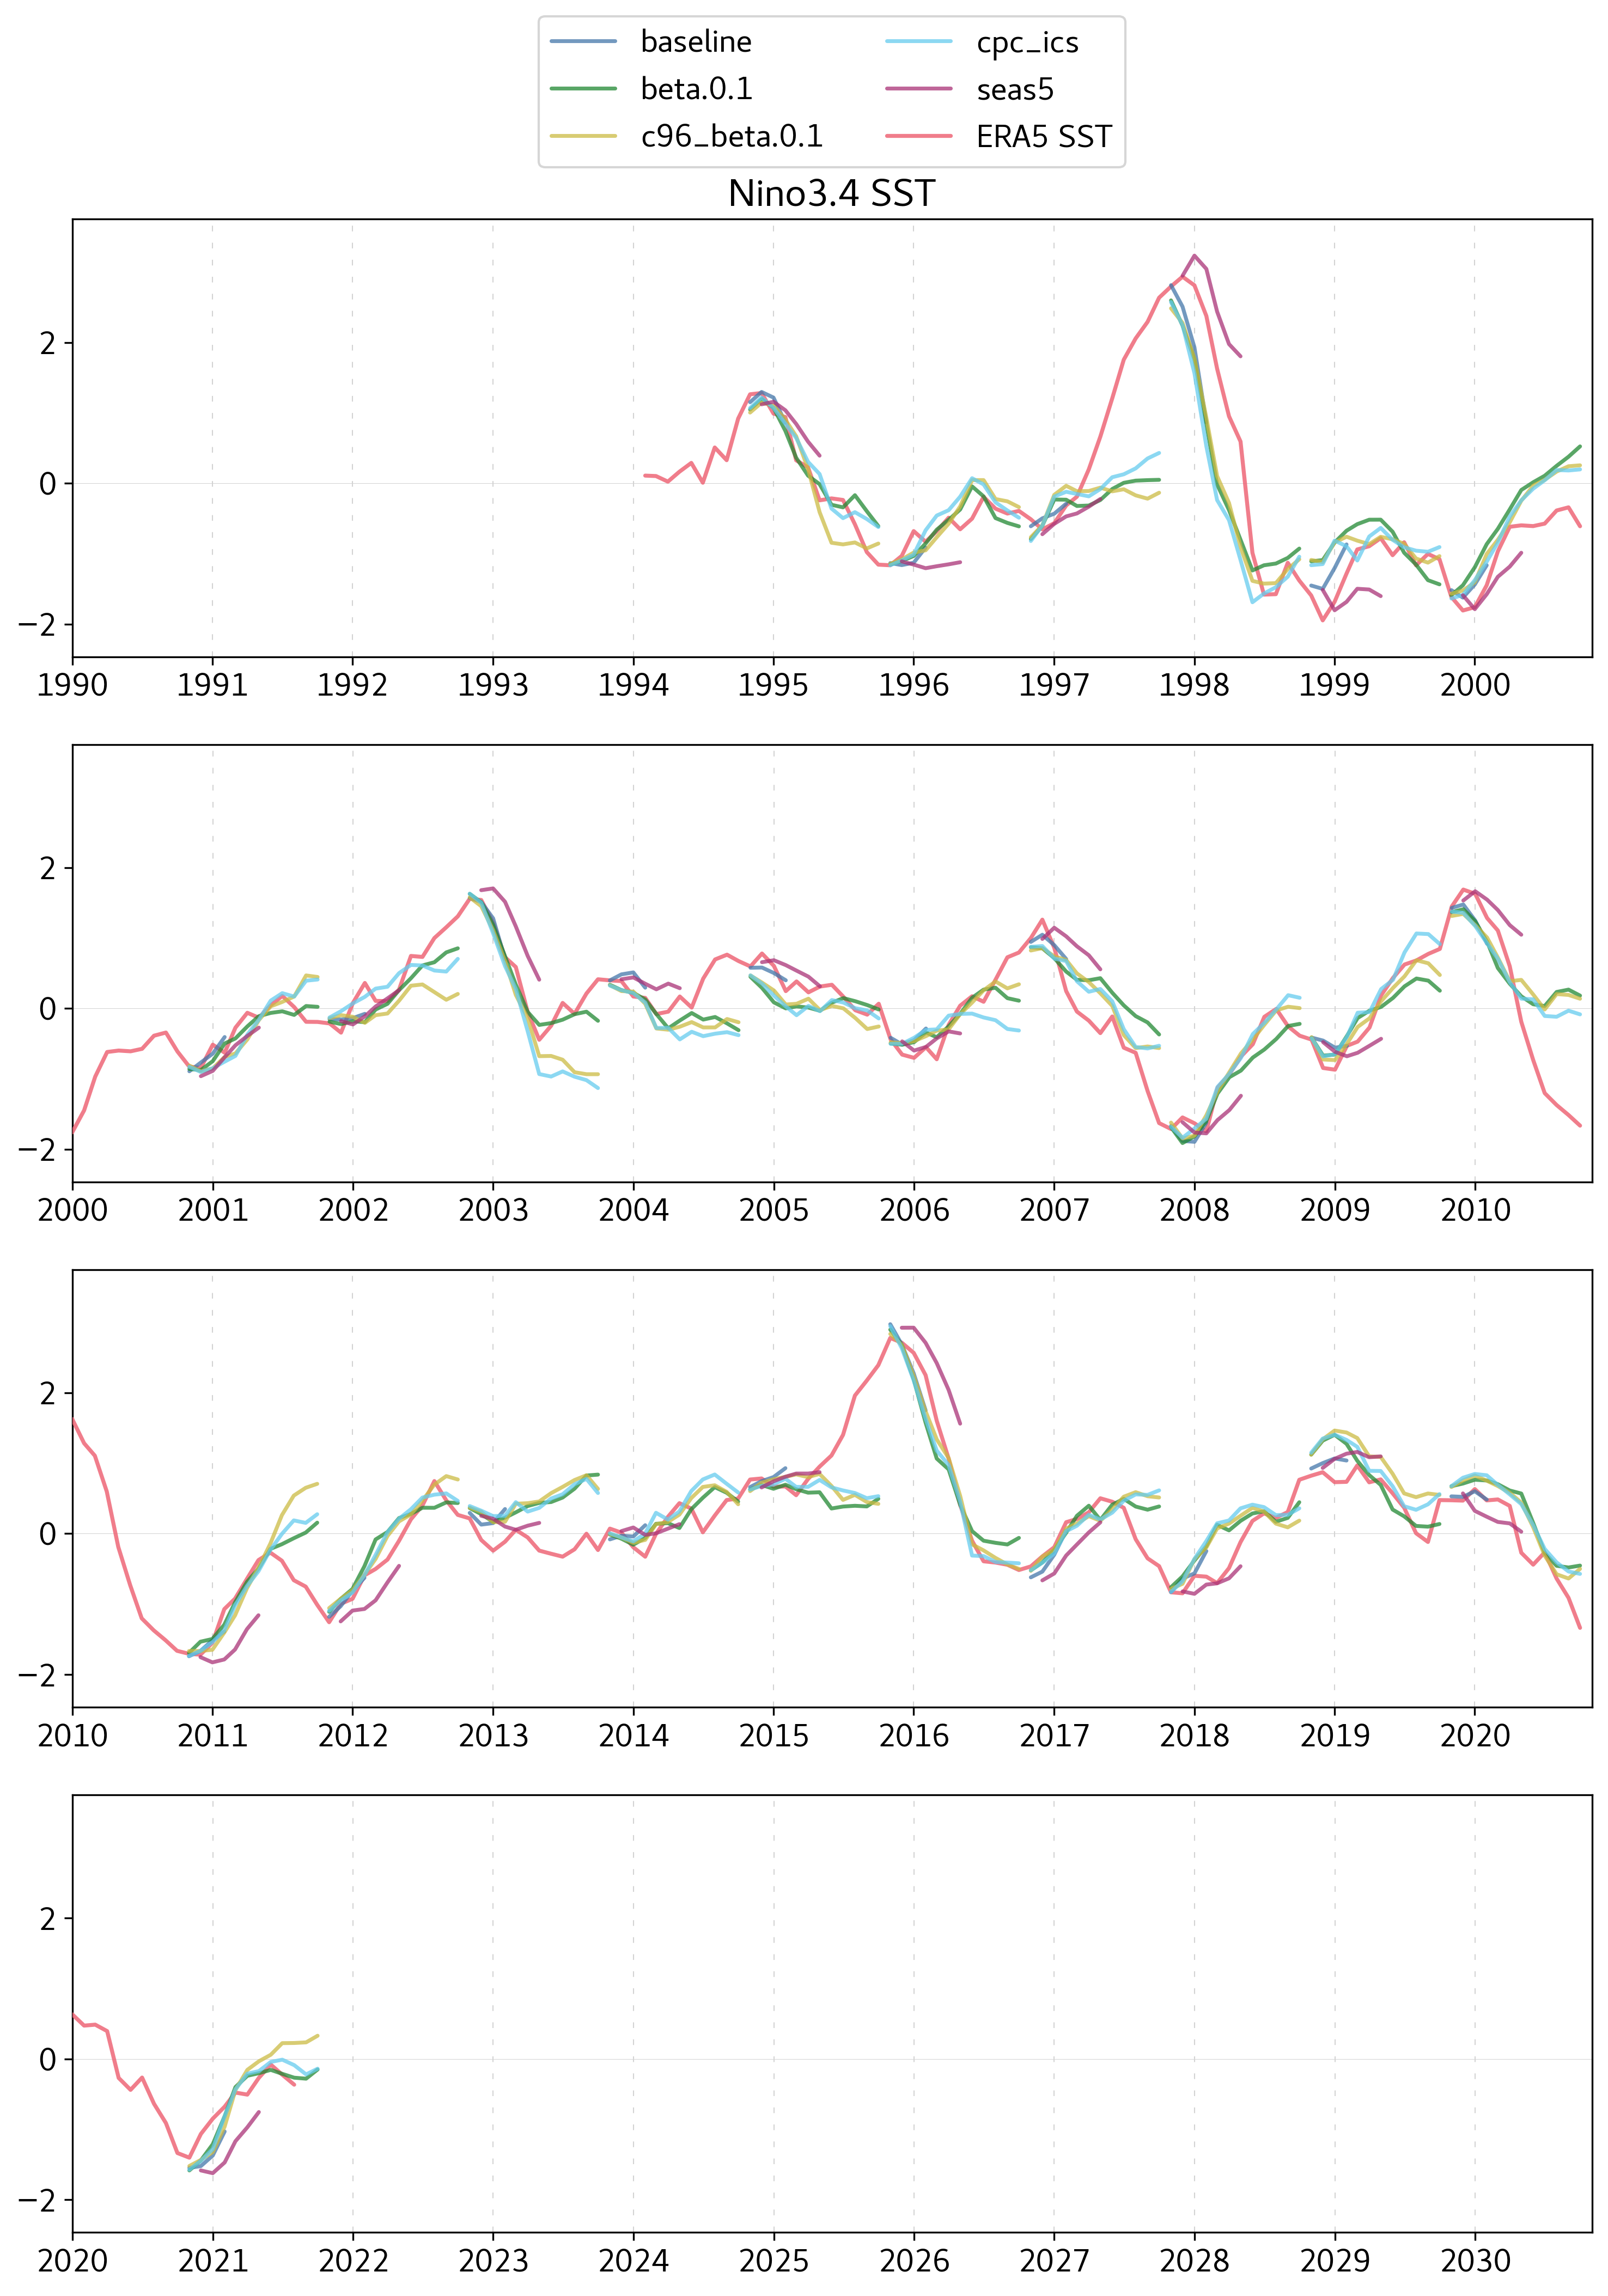

In [31]:
stats.plot_index_spaghetti(ufs_stats=ufs_stats,
                           verif_stats=era5_stats,
                           calc_anomaly=True,
                           title=f'Nino3.4 SST',
                           verif_label='ERA5 SST',
                           dpi=300)